In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from downloaded file 
data = pd.read_csv('NASA_data.csv', comment='#')

print(data.info())
#print(data.columns)

#keep only default measurements for each planet since the nasa table contains each planet multiple times
data = data[data['default_flag'] == 1]
# retrieve Radius, oribital period, stellar properties (effective temp, metallicity, mass), equilibrium temperature
filtered_cols = ['pl_name', 'pl_radj', 'pl_orbper', 'pl_eqt', 'pl_insol', 'pl_massj', 'st_teff', 'st_met', 'st_mass']
filtered_data = data[filtered_cols]
#print(filtered_data)

# filter for hot jupiters
# define a hot jupiter by radius > 0,8 jupiter radius and oribal period < 10
hot_jupiters = filtered_data[(filtered_data['pl_orbper'] < 10) & (filtered_data['pl_radj'] > 0.8)& (filtered_data['pl_radj'] < 2) &(filtered_data['pl_massj'] < 11.8) &(filtered_data['pl_massj'] > 0.36) ]

#all planets with all columns that are hot jupiters

candidates = data[(filtered_data['pl_orbper'] < 10) & (filtered_data['pl_radj'] > 0.8) & (filtered_data['pl_radj'] < 2) &(filtered_data['pl_massj'] < 11.8) &(filtered_data['pl_massj'] > 0.36) ]
#handle NaNs 
# first approach/idea: drop the whole line if radius or equilibrium temperature is missing
hot_jupiters = hot_jupiters.dropna(subset=['pl_radj', 'pl_eqt'])
print(hot_jupiters)


<class 'pandas.DataFrame'>
RangeIndex: 39476 entries, 0 to 39475
Columns: 108 entries, pl_name to releasedate
dtypes: float64(88), int64(4), str(16)
memory usage: 32.5 MB
None
          pl_name  pl_radj  pl_orbper  pl_eqt  pl_insol  pl_massj  st_teff  \
278     CoRoT-1 b    1.490   1.508956  1898.0       NaN     1.030   5950.0   
294    CoRoT-11 b    1.430   2.994330  1657.0       NaN     2.330   6440.0   
297    CoRoT-12 b    1.440   2.828042  1442.0       NaN     0.917   5675.0   
302    CoRoT-13 b    0.885   4.035190  1700.0       NaN     1.308   5945.0   
308    CoRoT-14 b    1.090   1.512140  1952.0       NaN     7.600   6035.0   
...           ...      ...        ...     ...       ...       ...      ...   
39249      XO-1 b    1.140   3.941530     NaN       NaN     0.830   5750.0   
39264    XO-2 N b    0.993   2.615862     NaN       NaN     0.566      NaN   
39303      XO-4 b    1.250   4.125080     NaN       NaN     1.420   6397.0   
39313      XO-5 b    1.140   4.187756  1230.

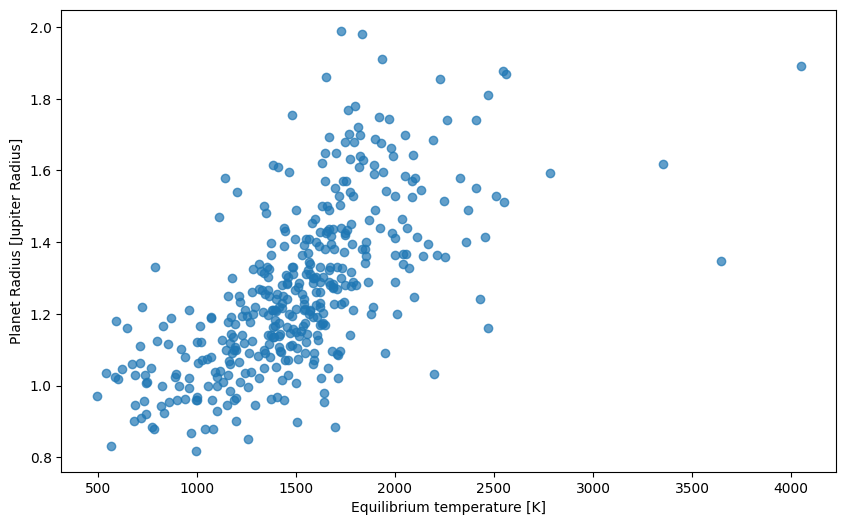

In [54]:
#create radius vs equilibrium temperature plot
#use plt.scatter instead of plt.plot which draws lines
'''
plt.figure(figsize=(10,6))
plt.plot(hot_jupiters['pl_eqt'],hot_jupiters['pl_radj'])
plt.xlabel("Equilibrium temperature (pl_eqt)")
plt.ylabel("Radius (pl_radj)")
plt.show()
'''
plt.figure(figsize=(10,6))
plt.scatter(hot_jupiters['pl_eqt'],hot_jupiters['pl_radj'], alpha=0.7)
plt.xlabel("Equilibrium temperature [K]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.show()

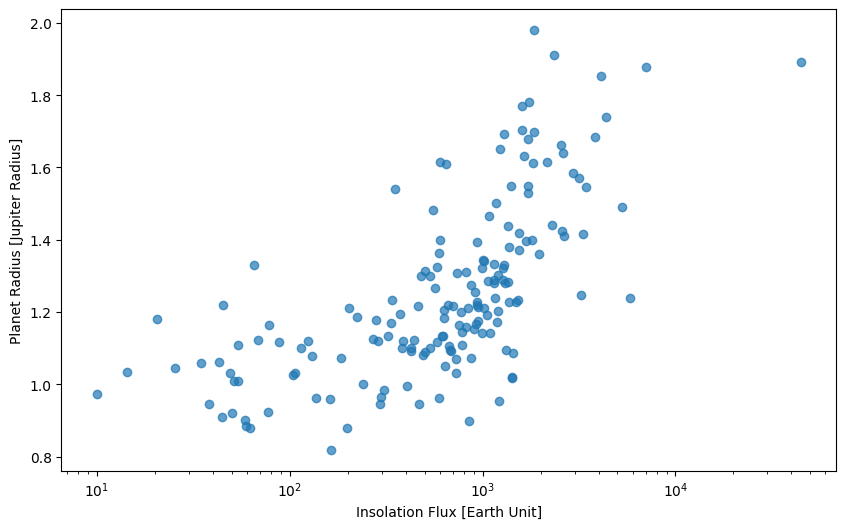

In [55]:
#analyze influence of incident flux
#use pl_insol -> Insolation Flux (earth flux)
#print(data.columns)
plt.figure(figsize=(10,6))
plt.scatter(hot_jupiters['pl_insol'], hot_jupiters['pl_radj'], alpha= 0.7)
plt.xlabel("Insolation Flux [Earth Unit]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.xscale('log')
plt.show()

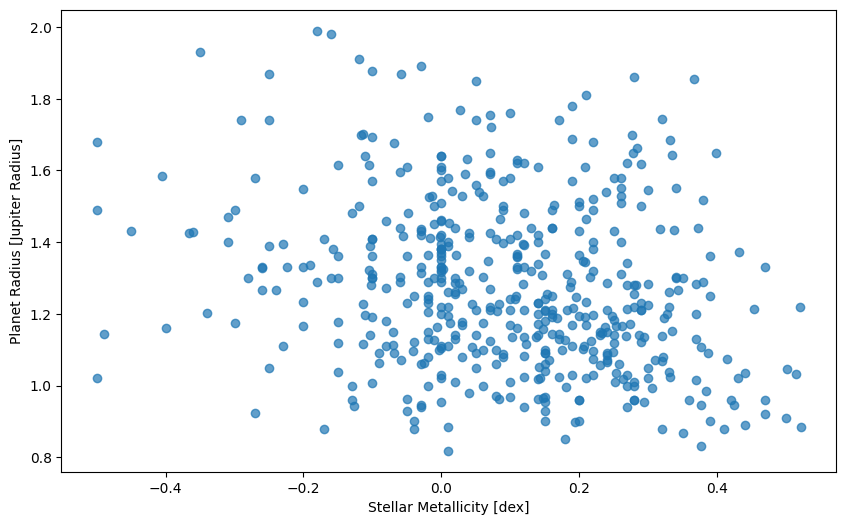

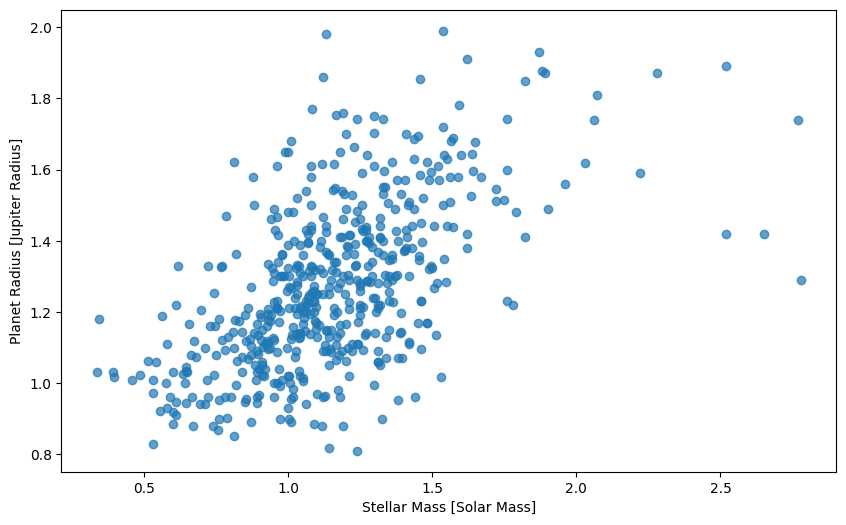

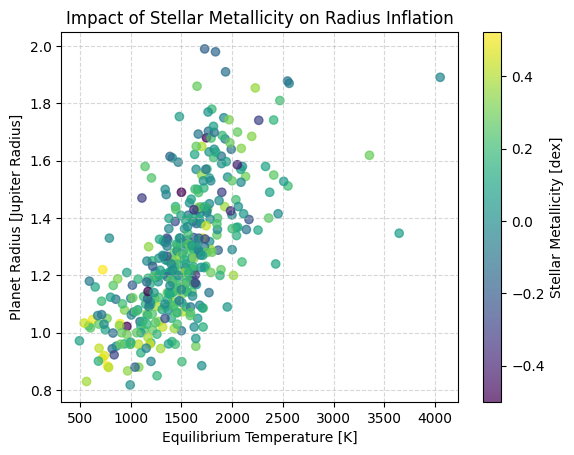

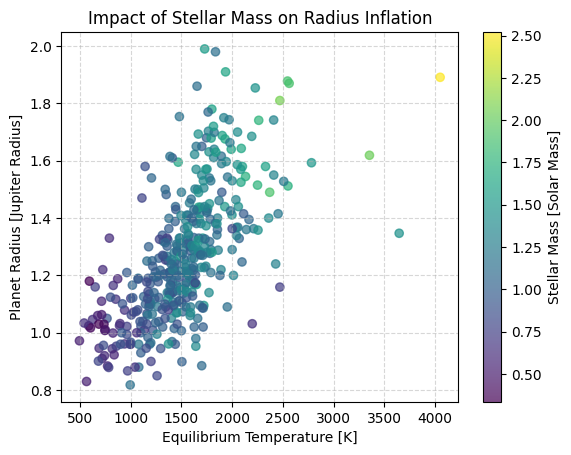

In [ ]:
#analyze the influence of stellar properties like mass or metallicity

#plot radius vs metallicity
plt.figure(figsize=(10,6))
plt.scatter(hot_jupiters['st_met'], hot_jupiters['pl_radj'], alpha= 0.7)
plt.xlabel("Stellar Metallicity [dex]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.show()

#plot radius vs stellar mass
plt.figure(figsize=(10,6))
plt.scatter(hot_jupiters['st_mass'], hot_jupiters['pl_radj'], alpha= 0.7)
plt.xlabel("Stellar Mass [Solar Mass]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.show()


#plt.figure(figsize=(10, 6))
#plot Temperature vs Radius
scatter = plt.scatter(hot_jupiters['pl_eqt'], hot_jupiters['pl_radj'], c=hot_jupiters['st_met'], alpha=0.7)
#Add colourbar to explain the colours
cbar = plt.colorbar(scatter)
cbar.set_label('Stellar Metallicity [dex]')
plt.xlabel("Equilibrium Temperature [K]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.title("Impact of Stellar Metallicity on Radius Inflation")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#plt.figure(figsize=(10, 6))
#plot Temperature vs Radius
scatter = plt.scatter(hot_jupiters['pl_eqt'], hot_jupiters['pl_radj'], c=hot_jupiters['st_mass'], alpha=0.7)
# Add colourbar to explain colours
cbar = plt.colorbar(scatter)
cbar.set_label('Stellar Mass [Solar Mass]')
plt.xlabel("Equilibrium Temperature [K]")
plt.ylabel("Planet Radius [Jupiter Radius]")
plt.title("Impact of Stellar Mass on Radius Inflation")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()